## 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Traditional supervised
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Load Dataset

In [3]:
df_raw = pd.read_csv('dataset/online_shoppers_intention.csv')
print(f"Shape dataset: {df_raw.shape}")
df_raw.head()


Shape dataset: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Exploratory Data Analysis (EDA)

### 3.1 Informasi Umum

In [4]:
print("=== Info Dataset ===")
df_raw.info()


=== Info Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType 

In [5]:
print("=== Statistik Deskriptif ===")
df_raw.describe().T


=== Statistik Deskriptif ===


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


### 3.2 Missing Values

In [6]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal missing values: {df_raw.isnull().sum().sum()}")


Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0


### 3.3 Distribusi Target Variable (Revenue)

Revenue
False    10422
True      1908
Name: count, dtype: int64

Imbalance ratio: 5.46:1


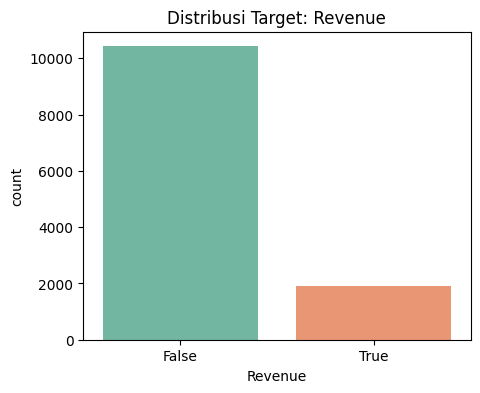

In [7]:
rev_counts = df_raw['Revenue'].value_counts()
print(rev_counts)
print(f"\nImbalance ratio: {rev_counts[False]/rev_counts[True]:.2f}:1")

plt.figure(figsize=(5,4))
sns.countplot(x='Revenue', data=df_raw, palette='Set2')
plt.title('Distribusi Target: Revenue')
plt.show()


### 3.4 Distribusi Kolom Numerik

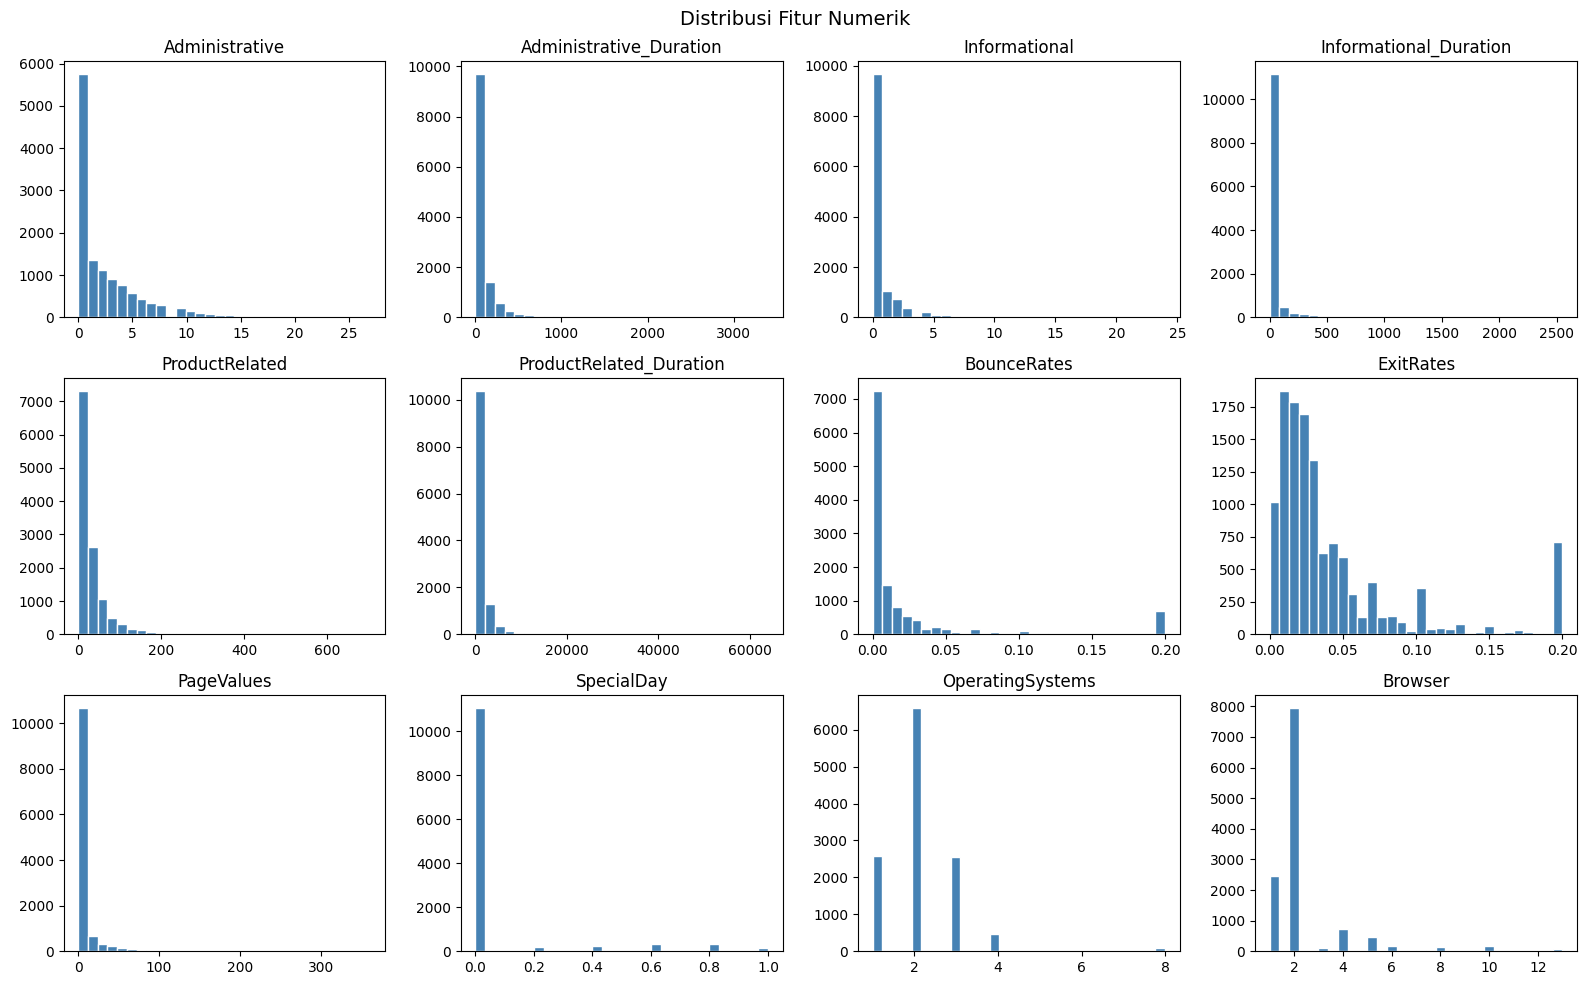

In [8]:
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:12]):
    axes[i].hist(df_raw[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
plt.suptitle('Distribusi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()


### 3.5 Deteksi Outlier (IQR Method)

In [9]:
def count_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

outlier_summary = pd.DataFrame({
    'Outlier Count': [count_outliers_iqr(df_raw[col]) for col in numeric_cols],
    'Outlier %': [(count_outliers_iqr(df_raw[col]) / len(df_raw) * 100).round(2) for col in numeric_cols]
}, index=numeric_cols)
print(outlier_summary)


                         Outlier Count  Outlier %
Administrative                     404       3.28
Administrative_Duration           1172       9.51
Informational                     2631      21.34
Informational_Duration            2405      19.51
ProductRelated                     987       8.00
ProductRelated_Duration            961       7.79
BounceRates                       1551      12.58
ExitRates                         1099       8.91
PageValues                        2730      22.14
SpecialDay                        1251      10.15
OperatingSystems                   111       0.90
Browser                           4369      35.43
Region                             511       4.14
TrafficType                       2101      17.04


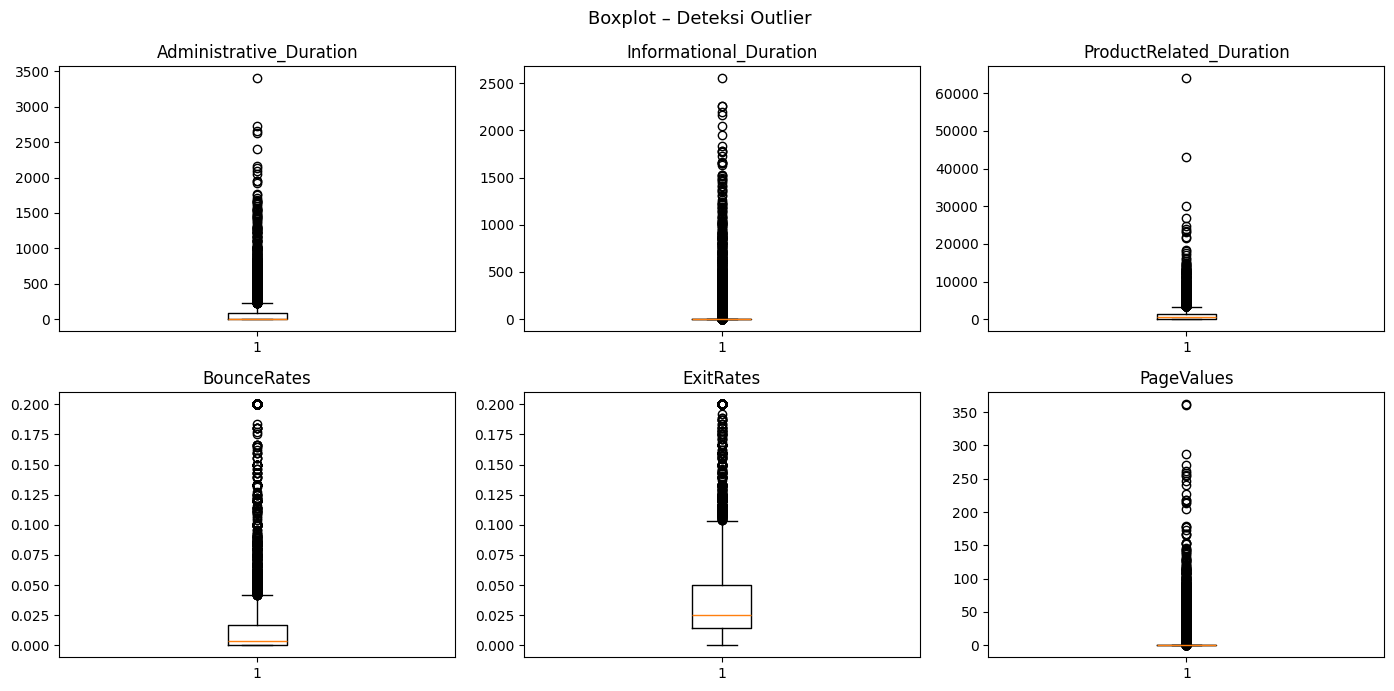

In [10]:
# Boxplot outlier untuk beberapa fitur kunci
key_features = ['Administrative_Duration', 'Informational_Duration',
                'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(key_features):
    axes[i].boxplot(df_raw[col].dropna())
    axes[i].set_title(col)
plt.suptitle('Boxplot – Deteksi Outlier', fontsize=13)
plt.tight_layout()
plt.show()


### 3.6 Korelasi Fitur Numerik

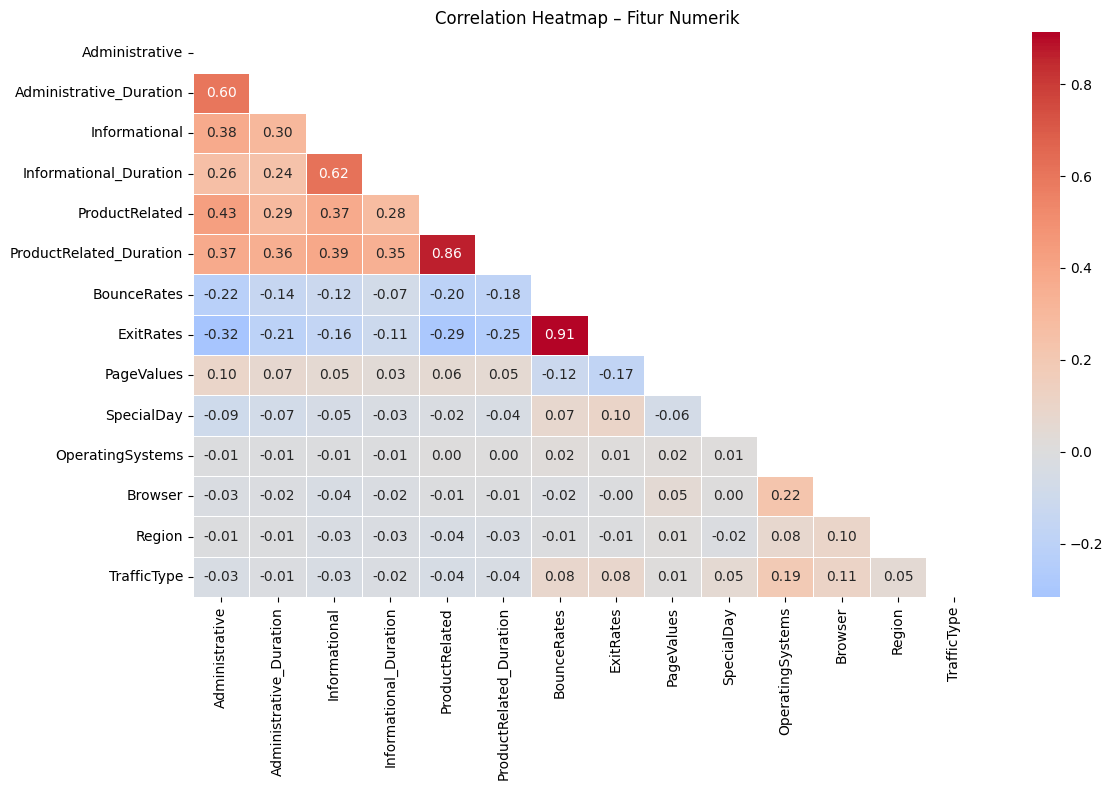

In [11]:
plt.figure(figsize=(12, 8))
corr_matrix = df_raw[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap – Fitur Numerik')
plt.tight_layout()
plt.show()


### 3.7 Distribusi Fitur Kategorikal

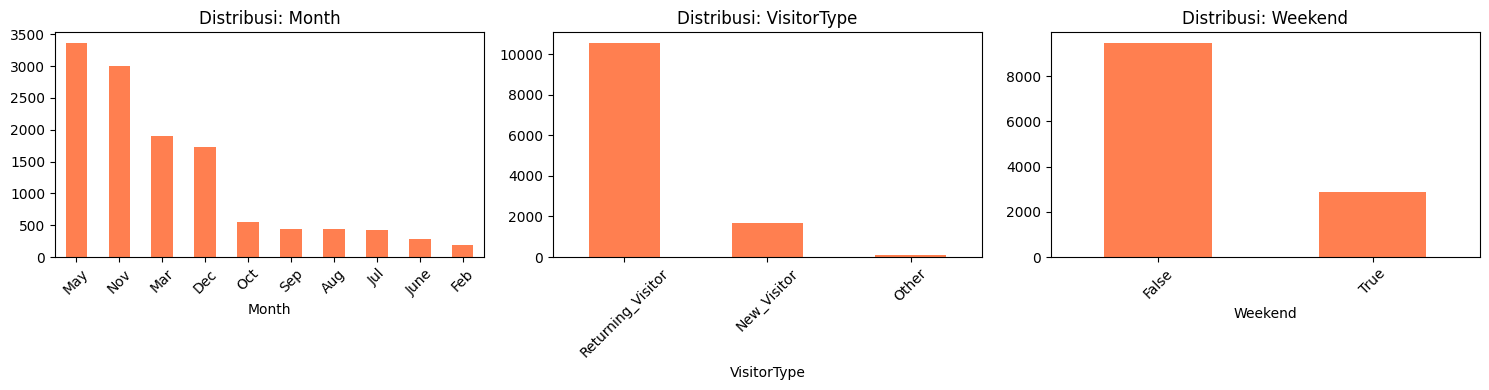

In [12]:
cat_cols = ['Month', 'VisitorType', 'Weekend']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cat_cols):
    df_raw[col].value_counts().plot(kind='bar', ax=axes[i], color='coral')
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## 4. Data Preprocessing

### 4.1 Konversi Tipe Data & Encoding

In [13]:
df = df_raw.copy()

df['Weekend'] = df['Weekend'].astype(int)
df['Revenue']  = df['Revenue'].astype(int)   # target: 0 / 1

#Label Encoding: VisitorType (ordinal-like)
visitor_map = {'Returning_Visitor': 2, 'New_Visitor': 1, 'Other': 0}
df['VisitorType'] = df['VisitorType'].map(visitor_map)

#Label Encoding: Month
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_map = {m: i for i, m in enumerate(month_order)}
df['Month'] = df['Month'].map(month_map)

print("Tipe data setelah encoding:")
print(df.dtypes)
print(f"\nNaN setelah mapping: {df.isnull().sum().sum()}")


Tipe data setelah encoding:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                        int64
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                  int64
Weekend                      int64
Revenue                      int64
dtype: object

NaN setelah mapping: 0


### 4.2 Penanganan Missing Values

In [14]:
# Setelah mapping Month/VisitorType, cek NaN (bulan yang tidak ada di map akan jadi NaN)
print("Missing setelah encoding:")
print(df.isnull().sum())

# Imputasi median untuk kolom numerik (jika ada NaN)
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

print(f"\nTotal missing setelah imputasi: {df.isnull().sum().sum()}")


Missing setelah encoding:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Total missing setelah imputasi: 0


### 4.3 Penanganan Outlier (Capping / Winsorization)

In [15]:
# Kap outlier pada persentil 1%-99% untuk fitur durasi & rates
cap_features = ['Administrative_Duration', 'Informational_Duration',
                'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']

for col in cap_features:
    lower_cap = df[col].quantile(0.01)
    upper_cap = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower_cap, upper=upper_cap)

print("Outlier telah di-cap pada persentil 1%-99%.")
print(f"Shape setelah preprocessing: {df.shape}")


Outlier telah di-cap pada persentil 1%-99%.
Shape setelah preprocessing: (12330, 18)


### 4.4 Seleksi Fitur untuk Modeling

In [16]:
# Fitur yang digunakan (semua kolom kecuali target)
FEATURE_COLS = [c for c in df.columns if c != 'Revenue']
TARGET_COL    = 'Revenue'

X_all = df[FEATURE_COLS].copy()
y_all = df[TARGET_COL].copy()

print(f"Jumlah fitur: {X_all.shape[1]}")
print(f"Distribusi target:\n{y_all.value_counts()}")


Jumlah fitur: 17
Distribusi target:
Revenue
0    10422
1     1908
Name: count, dtype: int64


### 4.5 Normalisasi (StandardScaler)

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURE_COLS)
print("Statistik setelah scaling (mean ≈ 0, std ≈ 1):")
print(X_scaled_df.describe().round(3).T[['mean', 'std']].head(10))


Statistik setelah scaling (mean ≈ 0, std ≈ 1):
                         mean  std
Administrative           -0.0  1.0
Administrative_Duration   0.0  1.0
Informational            -0.0  1.0
Informational_Duration   -0.0  1.0
ProductRelated            0.0  1.0
ProductRelated_Duration  -0.0  1.0
BounceRates              -0.0  1.0
ExitRates                 0.0  1.0
PageValues               -0.0  1.0
SpecialDay                0.0  1.0


### 4.6 Train-Test Split (Stratified)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all   # jaga proporsi kelas di train & test
)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")
print(f"\nProporsi Revenue=1 di train : {y_train.mean():.3f}")
print(f"Proporsi Revenue=1 di test  : {y_test.mean():.3f}")


Train size : 9864 samples
Test size  : 2466 samples

Proporsi Revenue=1 di train : 0.155
Proporsi Revenue=1 di test  : 0.155


## 5. Unsupervised Learning – K-Means Clustering

### 5.1 Elbow Method

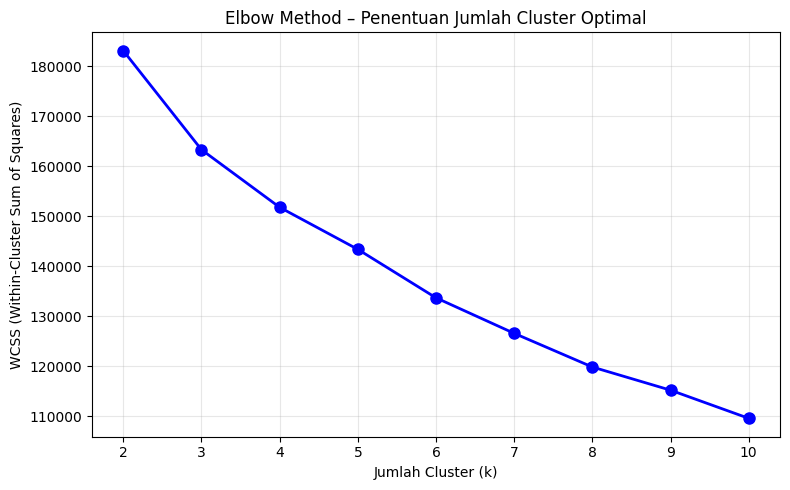

In [19]:
wcss = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method – Penentuan Jumlah Cluster Optimal')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 5.2 Silhouette Score

  k= 2  |  Silhouette Score: 0.2603
  k= 3  |  Silhouette Score: 0.2432
  k= 4  |  Silhouette Score: 0.1790
  k= 5  |  Silhouette Score: 0.1525
  k= 6  |  Silhouette Score: 0.1924
  k= 7  |  Silhouette Score: 0.1583
  k= 8  |  Silhouette Score: 0.1654
  k= 9  |  Silhouette Score: 0.1649
  k=10  |  Silhouette Score: 0.1423

Best k berdasarkan Silhouette Score: k = 2


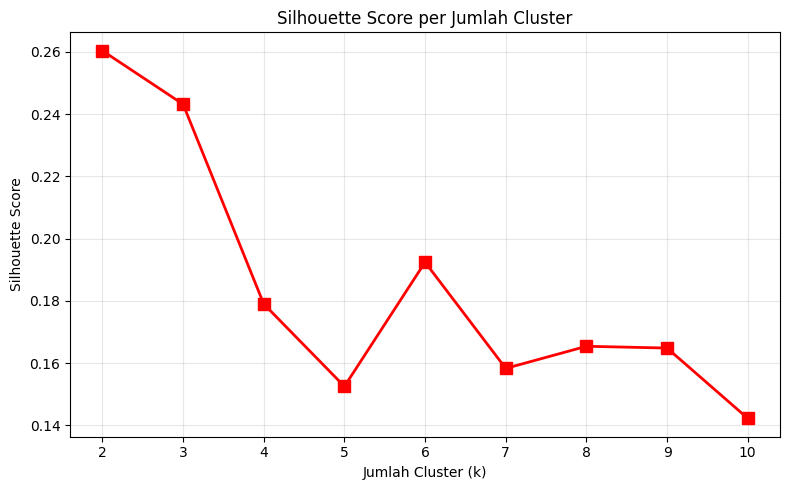

In [20]:
sil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"  k={k:2d}  |  Silhouette Score: {score:.4f}")

best_k = K_range[np.argmax(sil_scores)]
print(f"\nBest k berdasarkan Silhouette Score: k = {best_k}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, sil_scores, 'rs-', linewidth=2, markersize=8)
plt.title('Silhouette Score per Jumlah Cluster')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 5.3 Final K-Means (k=2)

In [21]:
# k=2 dipilih karena: (1) data biner Revenue memberikan struktur 2 kelompok alami,
# (2) Silhouette score k=2 umumnya kompetitif, (3) interpretasi lebih jelas.
OPTIMAL_K = 2

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

print(f"Jumlah sampel per cluster:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} sampel ({c/len(cluster_labels)*100:.1f}%)")
print(f"\nInertia (WCSS) final: {kmeans_final.inertia_:.2f}")
final_sil = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score final: {final_sil:.4f}")


Jumlah sampel per cluster:
  Cluster 0: 10292 sampel (83.5%)
  Cluster 1: 2038 sampel (16.5%)

Inertia (WCSS) final: 183137.81
Silhouette Score final: 0.2603


### 5.4 Visualisasi Cluster (PCA 2D)

Variansi dijelaskan oleh 2 PC: 31.32%


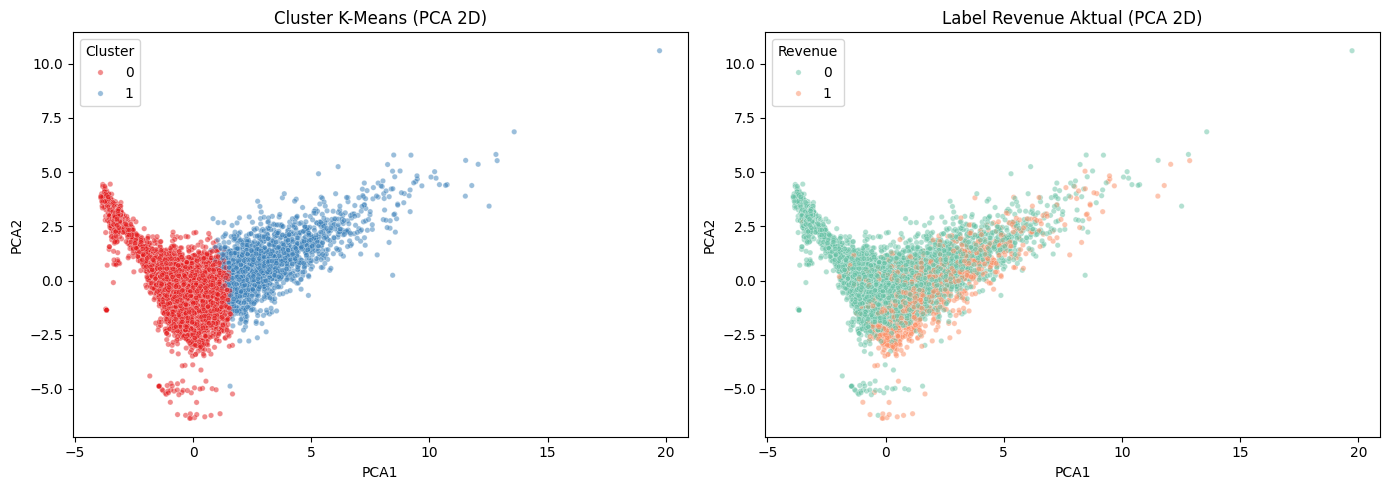

In [22]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PCA1'    : pca_result[:, 0],
    'PCA2'    : pca_result[:, 1],
    'Cluster' : cluster_labels,
    'Revenue' : y_all.values
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot by Cluster
sns.scatterplot(ax=axes[0], data=pca_df, x='PCA1', y='PCA2',
                hue='Cluster', palette='Set1', alpha=0.5, s=15)
axes[0].set_title('Cluster K-Means (PCA 2D)')

# Plot by Revenue (ground truth)
sns.scatterplot(ax=axes[1], data=pca_df, x='PCA1', y='PCA2',
                hue='Revenue', palette='Set2', alpha=0.5, s=15)
axes[1].set_title('Label Revenue Aktual (PCA 2D)')

print(f"Variansi dijelaskan oleh 2 PC: {pca.explained_variance_ratio_.sum():.2%}")
plt.tight_layout()
plt.show()


### 5.5 Profil Tiap Cluster

In [23]:
# Tambahkan cluster label ke dataframe asli (tidak dinormalisasi) untuk interpretasi
df_cluster = df[FEATURE_COLS + [TARGET_COL]].copy()
df_cluster['Cluster'] = cluster_labels

cluster_profile = df_cluster.groupby('Cluster').mean().round(3)
print("=== Profil Rata-Rata Tiap Cluster ===")
cluster_profile.T


=== Profil Rata-Rata Tiap Cluster ===


Cluster,0,1
Administrative,1.398,6.948
Administrative_Duration,39.502,261.286
Informational,0.171,2.184
Informational_Duration,5.699,154.687
ProductRelated,20.539,88.254
ProductRelated_Duration,739.463,3239.877
BounceRates,0.025,0.006
ExitRates,0.048,0.020
PageValues,4.654,9.373
SpecialDay,0.068,0.028


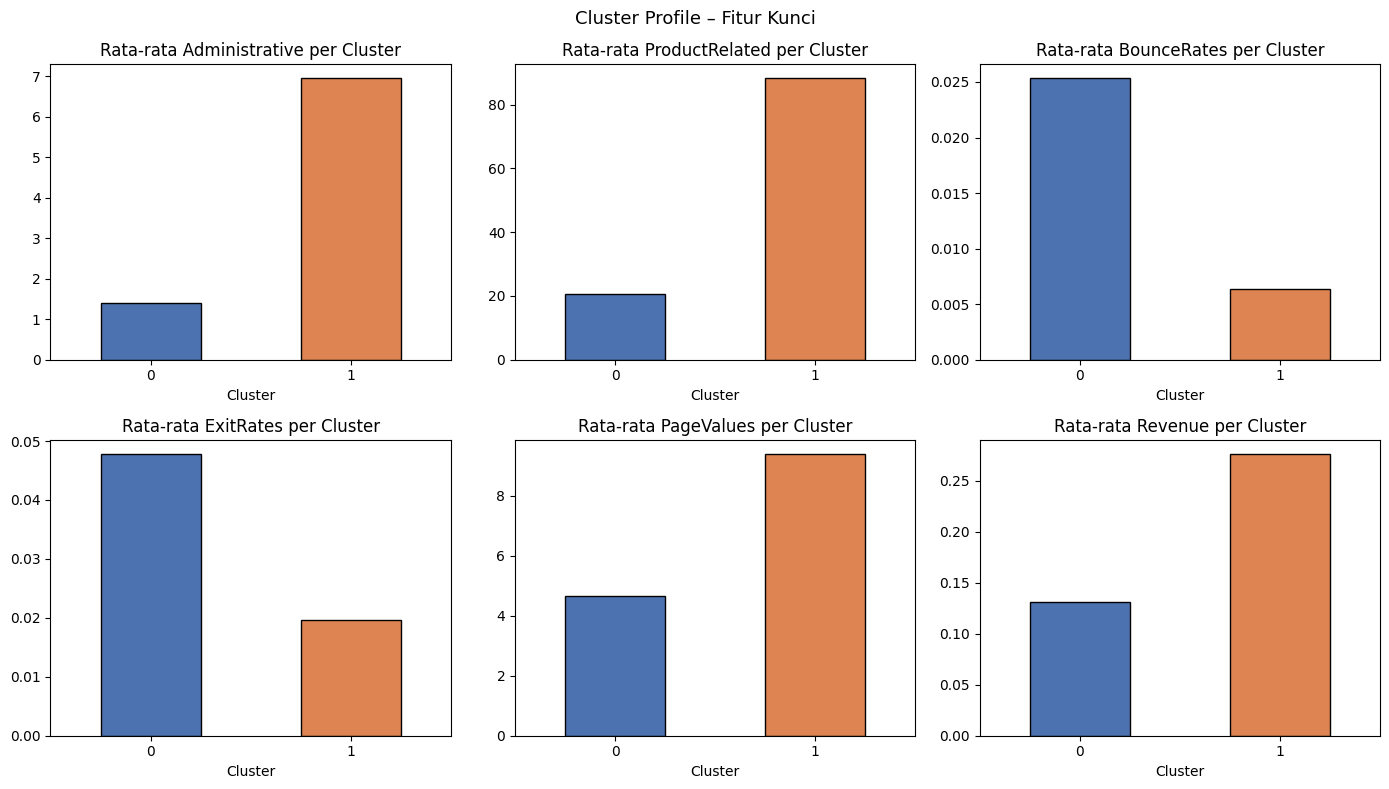

In [24]:
# Visualisasi profil beberapa fitur kunci antar cluster
profile_features = ['Administrative', 'ProductRelated', 'BounceRates',
                    'ExitRates', 'PageValues', 'Revenue']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, feat in enumerate(profile_features):
    df_cluster.groupby('Cluster')[feat].mean().plot(
        kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='black')
    axes[i].set_title(f'Rata-rata {feat} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].tick_params(axis='x', rotation=0)
plt.suptitle('Cluster Profile – Fitur Kunci', fontsize=13)
plt.tight_layout()
plt.show()


In [25]:
#Statistik angka spesifik untuk narasi interpretasi
print("=== PROFIL DETAIL PER CLUSTER ===\n")

key_feat = ['BounceRates', 'ExitRates', 'PageValues',
            'ProductRelated_Duration', 'Administrative_Duration', 'Revenue']

for feat in key_feat:
    vals = df_cluster.groupby('Cluster')[feat].mean()
    ratio = vals[1] / vals[0] if vals[0] != 0 else float('inf')
    print(f"{feat:30s} | Cluster 0: {vals[0]:8.4f} | Cluster 1: {vals[1]:8.4f} | Rasio C1/C0: {ratio:.2f}x")

print()
print("=== DISTRIBUSI REVENUE PER CLUSTER ===")
for cl in [0, 1]:
    n_total = (df_cluster['Cluster'] == cl).sum()
    n_buy   = ((df_cluster['Cluster'] == cl) & (df_cluster['Revenue'] == 1)).sum()
    print(f"  Cluster {cl}: {n_total:5d} sampel | Revenue=1: {n_buy:4d} ({n_buy/n_total*100:.1f}%)")


=== PROFIL DETAIL PER CLUSTER ===

BounceRates                    | Cluster 0:   0.0253 | Cluster 1:   0.0064 | Rasio C1/C0: 0.25x
ExitRates                      | Cluster 0:   0.0477 | Cluster 1:   0.0196 | Rasio C1/C0: 0.41x
PageValues                     | Cluster 0:   4.6543 | Cluster 1:   9.3728 | Rasio C1/C0: 2.01x
ProductRelated_Duration        | Cluster 0: 739.4630 | Cluster 1: 3239.8770 | Rasio C1/C0: 4.38x
Administrative_Duration        | Cluster 0:  39.5018 | Cluster 1: 261.2862 | Rasio C1/C0: 6.61x
Revenue                        | Cluster 0:   0.1308 | Cluster 1:   0.2758 | Rasio C1/C0: 2.11x

=== DISTRIBUSI REVENUE PER CLUSTER ===
  Cluster 0: 10292 sampel | Revenue=1: 1346 (13.1%)
  Cluster 1:  2038 sampel | Revenue=1:  562 (27.6%)


## 6. Supervised Learning – Model Tradisional

### 6.1 Naive Bayes

In [26]:
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)
y_pred_nb = model_nb.predict(X_test)

print("Naive Bayes")
print(classification_report(y_test, y_pred_nb, target_names=['Not Buy', 'Buy']))

acc_nb  = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb  = recall_score(y_test, y_pred_nb)
f1_nb   = f1_score(y_test, y_pred_nb)
print(f"Accuracy: {acc_nb:.4f} | Precision: {prec_nb:.4f} | Recall: {rec_nb:.4f} | F1: {f1_nb:.4f}")

Naive Bayes
              precision    recall  f1-score   support

     Not Buy       0.93      0.81      0.87      2084
         Buy       0.40      0.67      0.50       382

    accuracy                           0.79      2466
   macro avg       0.66      0.74      0.68      2466
weighted avg       0.85      0.79      0.81      2466

Accuracy: 0.7916 | Precision: 0.3978 | Recall: 0.6728 | F1: 0.5000


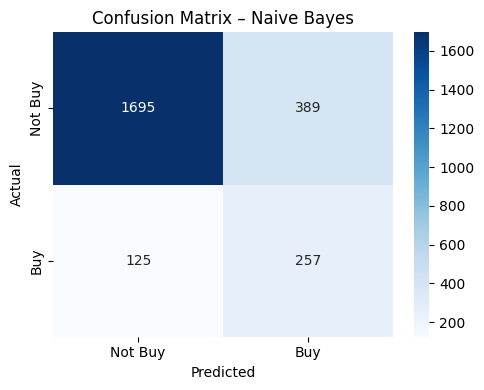

In [27]:
# Confusion Matrix Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Buy', 'Buy'], yticklabels=['Not Buy', 'Buy'])
plt.title('Confusion Matrix – Naive Bayes')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


### 6.2 Linear Discriminant Analysis (LDA)

In [28]:
model_lda = LinearDiscriminantAnalysis()
model_lda.fit(X_train, y_train)
y_pred_lda = model_lda.predict(X_test)

print("Linear Discriminant Analysis")
print(classification_report(y_test, y_pred_lda, target_names=['Not Buy', 'Buy']))

acc_lda  = accuracy_score(y_test, y_pred_lda)
prec_lda = precision_score(y_test, y_pred_lda)
rec_lda  = recall_score(y_test, y_pred_lda)
f1_lda   = f1_score(y_test, y_pred_lda)
print(f"Accuracy: {acc_lda:.4f} | Precision: {prec_lda:.4f} | Recall: {rec_lda:.4f} | F1: {f1_lda:.4f}")


Linear Discriminant Analysis
              precision    recall  f1-score   support

     Not Buy       0.89      0.97      0.93      2084
         Buy       0.72      0.37      0.49       382

    accuracy                           0.88      2466
   macro avg       0.81      0.67      0.71      2466
weighted avg       0.87      0.88      0.86      2466

Accuracy: 0.8808 | Precision: 0.7245 | Recall: 0.3717 | F1: 0.4913


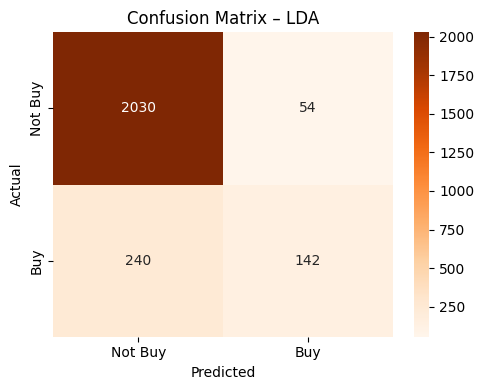

In [29]:
# Confusion Matrix LDA
cm_lda = confusion_matrix(y_test, y_pred_lda)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Buy', 'Buy'], yticklabels=['Not Buy', 'Buy'])
plt.title('Confusion Matrix – LDA')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


## 7. Supervised Learning – ANN / Deep Learning (Model Modern)

In [30]:
# Konversi target ke array float untuk Keras
y_train_arr = y_train.values.astype('float32')
y_test_arr  = y_test.values.astype('float32')

# Bangun arsitektur ANN
tf.random.set_seed(42)

model_ann = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_ann.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model_ann.fit(
    X_train, y_train_arr,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8268 - loss: 0.4275 - val_accuracy: 0.8860 - val_loss: 0.2912
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8827 - loss: 0.2995 - val_accuracy: 0.8941 - val_loss: 0.2684
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8854 - loss: 0.2832 - val_accuracy: 0.8931 - val_loss: 0.2624
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8928 - loss: 0.2665 - val_accuracy: 0.8900 - val_loss: 0.2589
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8930 - loss: 0.2641 - val_accuracy: 0.8900 - val_loss: 0.2556
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8968 - loss: 0.2577 - val_accuracy: 0.8920 - val_loss: 0.2537
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8971 - loss: 0.2568 - val_accuracy: 0.8925 - val_loss: 0.2526
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8972 - loss: 0.2554 - val_accuracy: 0.

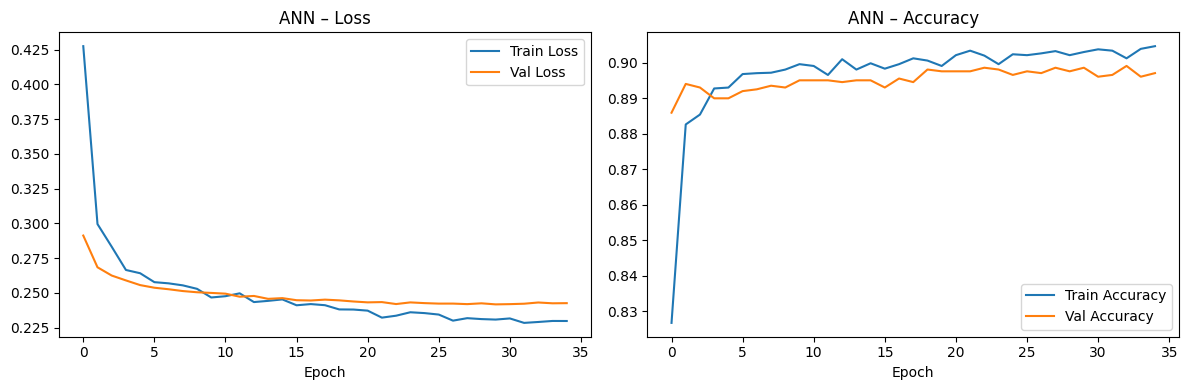

In [32]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('ANN – Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('ANN – Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


In [33]:
# Evaluasi ANN pada test set
y_prob_ann = model_ann.predict(X_test).flatten()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

print("Artificial Neural Network (ANN)")
print(classification_report(y_test_arr, y_pred_ann, target_names=['Not Buy', 'Buy']))

acc_ann  = accuracy_score(y_test_arr, y_pred_ann)
prec_ann = precision_score(y_test_arr, y_pred_ann)
rec_ann  = recall_score(y_test_arr, y_pred_ann)
f1_ann   = f1_score(y_test_arr, y_pred_ann)
print(f"Accuracy: {acc_ann:.4f} | Precision: {prec_ann:.4f} | Recall: {rec_ann:.4f} | F1: {f1_ann:.4f}")


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Artificial Neural Network (ANN)
              precision    recall  f1-score   support

     Not Buy       0.92      0.95      0.93      2084
         Buy       0.67      0.55      0.60       382

    accuracy                           0.89      2466
   macro avg       0.79      0.75      0.77      2466
weighted avg       0.88      0.89      0.88      2466

Accuracy: 0.8881 | Precision: 0.6688 | Recall: 0.5497 | F1: 0.6034


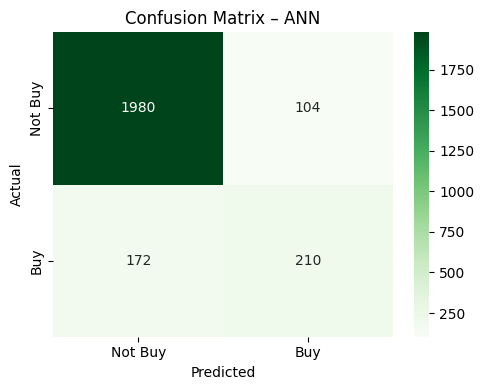

In [34]:
# Confusion Matrix ANN
cm_ann = confusion_matrix(y_test_arr, y_pred_ann)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Buy', 'Buy'], yticklabels=['Not Buy', 'Buy'])
plt.title('Confusion Matrix – ANN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


## 8. Model Benchmarking – Perbandingan Performa

In [35]:
benchmark_df = pd.DataFrame({
    'Model'    : ['Naive Bayes', 'LDA', 'ANN (Deep Learning)'],
    'Accuracy' : [acc_nb,  acc_lda,  acc_ann],
    'Precision': [prec_nb, prec_lda, prec_ann],
    'Recall'   : [rec_nb,  rec_lda,  rec_ann],
    'F1-Score' : [f1_nb,   f1_lda,   f1_ann],
    'Kategori' : ['Tradisional', 'Tradisional', 'Modern']
})

benchmark_df = benchmark_df.set_index('Model')
print(" Tabel Perbandingan Metrik")
benchmark_df.round(4)


 Tabel Perbandingan Metrik


,Accuracy,Precision,Recall,F1-Score,Kategori
Model,,,,,
Naive Bayes,0.7916,0.3978,0.6728,0.5000,Tradisional
LDA,0.8808,0.7245,0.3717,0.4913,Tradisional
ANN (Deep Learning),0.8881,0.6688,0.5497,0.6034,Modern


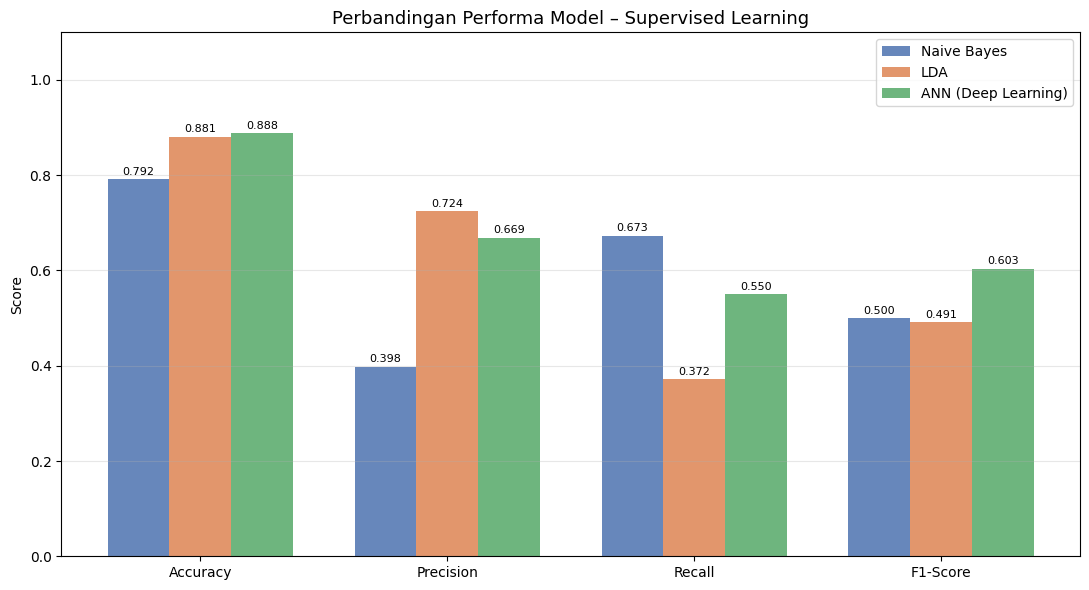

In [36]:
# Visualisasi benchmark
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x       = np.arange(len(metrics))
width   = 0.25
models  = ['Naive Bayes', 'LDA', 'ANN (Deep Learning)']
colors  = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(11, 6))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [benchmark_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Perbandingan Performa Model – Supervised Learning', fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


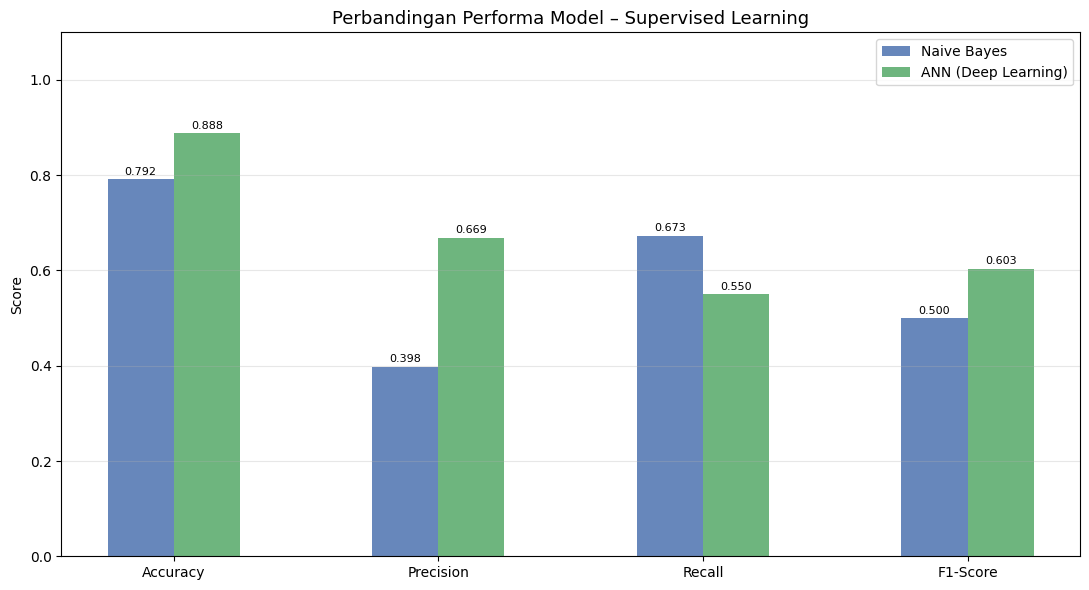

In [40]:
# Visualisasi benchmark
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x       = np.arange(len(metrics))
width   = 0.25
models  = ['Naive Bayes', 'ANN (Deep Learning)']
colors  = ['#4C72B0', '#55A868']

fig, ax = plt.subplots(figsize=(11, 6))
for i, (model, color) in enumerate(zip(models, colors)):
    vals = [benchmark_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_title('Perbandingan Performa Model – Supervised Learning', fontsize=13)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Integration Analysis – Cluster vs Label Revenue

In [ ]:
# Crosstab Cluster vs Revenue
crosstab = pd.crosstab(cluster_labels, y_all.values,
                       rownames=['Cluster'], colnames=['Revenue (0=No, 1=Yes)'])
print("Crosstab: Cluster vs Revenue")
print(crosstab)
print()

# Proporsi Revenue=1 per cluster
for cl in range(OPTIMAL_K):
    mask_cl = cluster_labels == cl
    rev_rate = y_all.values[mask_cl].mean()
    print(f"Cluster {cl}: {mask_cl.sum()} sampel | Revenue=1 rate: {rev_rate:.2%}")


Crosstab: Cluster vs Revenue
Revenue (0=No, 1=Yes)     0     1
Cluster                          
0                      8946  1346
1                      1476   562

Cluster 0: 10292 sampel | Revenue=1 rate: 13.08%
Cluster 1: 2038 sampel | Revenue=1 rate: 27.58%


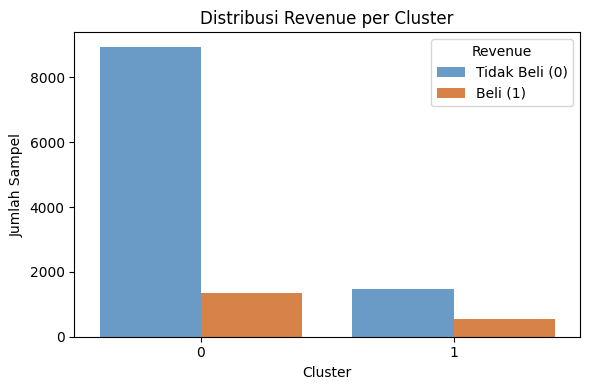

In [ ]:
# Visualisasi 1: Countplot Cluster vs Revenue
plt.figure(figsize=(6, 4))
temp_df = pd.DataFrame({'Cluster': cluster_labels, 'Revenue': y_all.values})
sns.countplot(x='Cluster', hue='Revenue', data=temp_df,
              palette={0: '#5B9BD5', 1: '#ED7D31'})
plt.title('Distribusi Revenue per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Sampel')
plt.legend(title='Revenue', labels=['Tidak Beli (0)', 'Beli (1)'])
plt.tight_layout()
plt.show()


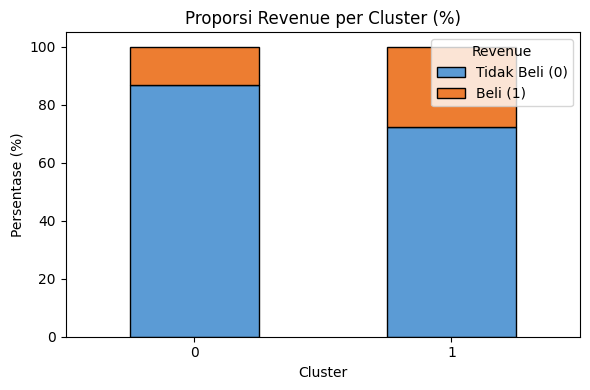

In [ ]:
# Visualisasi 2: Stacked bar – proporsi Revenue per cluster
crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
crosstab_pct.plot(kind='bar', stacked=True, figsize=(6, 4),
                  color=['#5B9BD5', '#ED7D31'], edgecolor='black')
plt.title('Proporsi Revenue per Cluster (%)')
plt.xlabel('Cluster')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Revenue', labels=['Tidak Beli (0)', 'Beli (1)'])
plt.tight_layout()
plt.show()


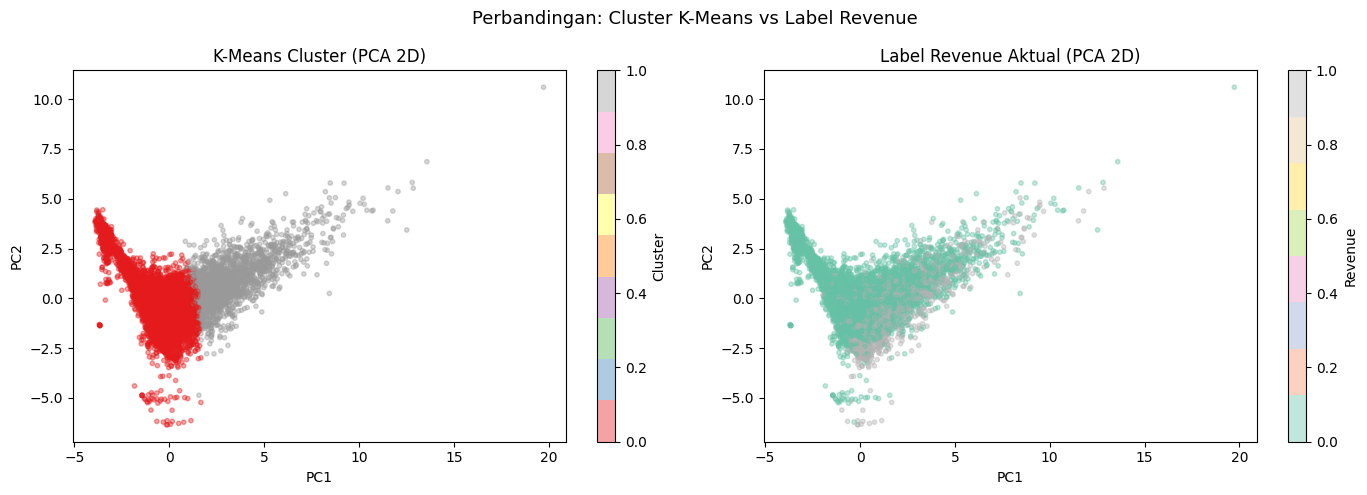

In [ ]:
# Visualisasi 3: PCA scatter diberi warna cluster & marker Revenue
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: warna = cluster
scatter1 = axes[0].scatter(pca_df['PCA1'], pca_df['PCA2'],
                           c=pca_df['Cluster'], cmap='Set1', alpha=0.4, s=10)
axes[0].set_title('K-Means Cluster (PCA 2D)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Kanan: warna = Revenue
scatter2 = axes[1].scatter(pca_df['PCA1'], pca_df['PCA2'],
                           c=pca_df['Revenue'], cmap='Set2', alpha=0.4, s=10)
axes[1].set_title('Label Revenue Aktual (PCA 2D)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Revenue')

plt.suptitle('Perbandingan: Cluster K-Means vs Label Revenue', fontsize=13)
plt.tight_layout()
plt.show()


## 10. Kesimpulan & Rekomendasi

In [ ]:
print("=" * 60)
print("RINGKASAN HASIL AKHIR")
print("=" * 60)

print(f"\nDataset: {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom")
print(f"Fitur digunakan: {len(FEATURE_COLS)}")
print(f"Distribusi target (Revenue=1): {y_all.mean()*100:.1f}%")

print(f"\nClustering (K-Means, k={OPTIMAL_K}):")
print(f"  Silhouette Score : {silhouette_score(X_scaled, cluster_labels):.4f}")
print(f"  WCSS (Inertia)   : {kmeans_final.inertia_:.2f}")

print(f"\nTrain-Test Split:")
print(f"  Train: {len(y_train):,} sampel | Revenue=1: {y_train.mean()*100:.1f}%")
print(f"  Test : {len(y_test):,} sampel  | Revenue=1: {y_test.mean()*100:.1f}%")

print(f"\nPerforma Model (Test Set):")
print(f"  {'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1-Score':>10}")
print(f"  {'-'*62}")
for name, a, p, r, f in [
    ('Naive Bayes',        acc_nb,  prec_nb,  rec_nb,  f1_nb),
    ('LDA',                acc_lda, prec_lda, rec_lda, f1_lda),
    ('ANN (Deep Learning)',acc_ann, prec_ann, rec_ann, f1_ann),
]:
    print(f"  {name:<22} {a:>9.4f} {p:>10.4f} {r:>8.4f} {f:>10.4f}")

# Model terbaik
scores = {'Naive Bayes': f1_nb, 'LDA': f1_lda, 'ANN (Deep Learning)': f1_ann}
best = max(scores, key=scores.get)
print(f"\n  Model terbaik berdasarkan F1-Score: {best} ({scores[best]:.4f})")

print(f"\nIntegration Analysis:")
for cl in [0, 1]:
    n  = (cluster_labels == cl).sum()
    r1 = ((cluster_labels == cl) & (y_all.values == 1)).sum()
    print(f"  Cluster {cl}: {n:,} sampel | Revenue=1: {r1:,} ({r1/n*100:.1f}%)")


RINGKASAN HASIL AKHIR

Dataset: 12,330 baris x 18 kolom
Fitur digunakan: 17
Distribusi target (Revenue=1): 15.5%

Clustering (K-Means, k=2):
  Silhouette Score : 0.2603
  WCSS (Inertia)   : 183137.81

Train-Test Split:
  Train: 9,864 sampel | Revenue=1: 15.5%
  Test : 2,466 sampel  | Revenue=1: 15.5%

Performa Model (Test Set):
  Model                   Accuracy  Precision   Recall   F1-Score
  --------------------------------------------------------------
  Naive Bayes               0.7916     0.3978   0.6728     0.5000
  LDA                       0.8808     0.7245   0.3717     0.4913
  ANN (Deep Learning)       0.8897     0.6698   0.5681     0.6147

  Model terbaik berdasarkan F1-Score: ANN (Deep Learning) (0.6147)

Integration Analysis:
  Cluster 0: 10,292 sampel | Revenue=1: 1,346 (13.1%)
  Cluster 1: 2,038 sampel | Revenue=1: 562 (27.6%)


In [ ]:
# Total pembeli
total_buyers = y_all.sum()
print(f"Total Revenue=1: {total_buyers}")

# Pembeli per cluster
df_check = pd.DataFrame({'Cluster': cluster_labels, 'Revenue': y_all.values})
print(df_check.groupby('Cluster')['Revenue'].sum())
print(df_check.groupby('Cluster')['Revenue'].mean().round(3))

Total Revenue=1: 1908
Cluster
0    1346
1     562
Name: Revenue, dtype: int64
Cluster
0    0.131
1    0.276
Name: Revenue, dtype: float64


In [42]:
print(df['Revenue'].value_counts())
print(df['Revenue'].value_counts(normalize=True).round(3) * 100)

Revenue
0    10422
1     1908
Name: count, dtype: int64
Revenue
0    84.5
1    15.5
Name: proportion, dtype: float64
